In [3]:
import pandas as pd
import numpy as np

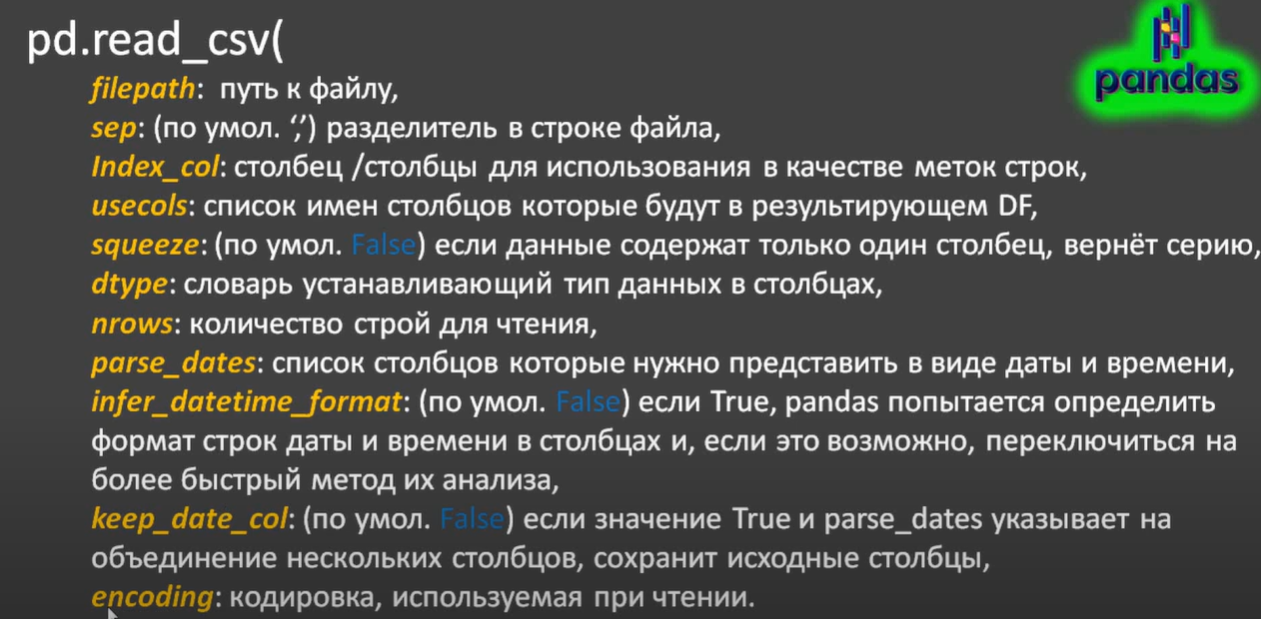

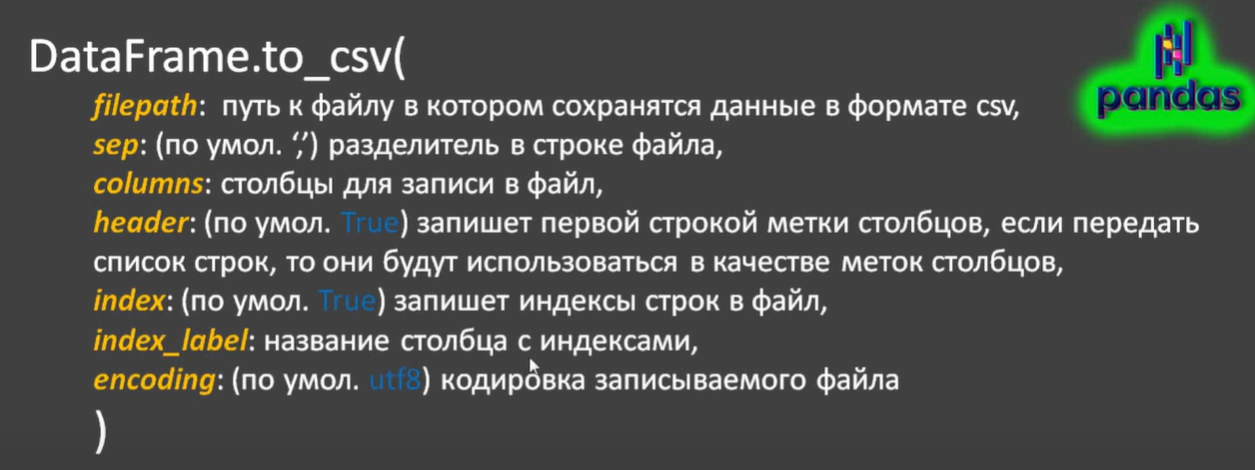

In [ ]:
df = pd.read_csv('/content/avito_data.csv')
df

In [ ]:
#Аргумент sep
df = pd.read_csv('/content/avito_data.csv',
                sep= ';')
df

In [ ]:
#Аргумент index_col
df = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                index_col= ['user_type'])
df

In [ ]:
#Аргумент usecols
df = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                index_col= ['user_type'],
                usecols= ['user_id', 'city', 'price', 'activation_date'] # выборка столбцов
                )
df

In [ ]:
#Аргумент squeeze
df_squeeze = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                usecols= ['city'], # выборка столбцов
                squeeze= True # если один столбец, то преобразует в Серию
                        )
df

In [ ]:
#Аргумент dtype
df_dtype = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                usecols= ['user_id', 'city', 'price', 'activation_date'] # выборка столбцов
                dtype={'city': 'category',}
                        )
df_dtype.info()

In [ ]:
#Аргумент nrows
df_nrows = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                nrows=5 #импортирует 5 строк
                      )
df_nrows

In [ ]:
#Аргумент parse_dates
df_parse_dates = pd.read_csv('/content/avito_data.csv',
                sep= ';',
                #parse_dates= ['activation_date', 'category_name', 'price']
                #parse_dates= [['year', 'month', 'day'],'activation_date']
                parse_dates= {'date0': ['activation_date'],
                              'date1': ['year', 'month', 'day']}
                             
df_parse_dates 
df_parse_dates.info()

In [ ]:
#Аргумент keep_date_col
df_parse_dates = pd.read_csv('/content/avito_data.csv',
                             sep= ';',
                             parse_dates= [['year', 'month', 'day']]
                             keep_date_col= True # не удаляет спарсенные столбцы
                             )
df_parse_dates

## Запись файлов CSV

In [ ]:
df.to_csv('avito_copy.csv')

In [ ]:
df.to_csv('avito_copy.csv',
         sep= ';')

In [ ]:
df.to_csv('avito_copy.csv',
         columns= ['city', 'price'])

In [ ]:
#Аргумент header
#Первая строка расценивается как метки столбцов
df.to_csv('avito_copy.csv',
         columns= ['city', 'price'],
         #header= True,
         header = ['city_copy', 'price_copy']
         )

In [ ]:
#Аргумент index
df.to_csv('avito_copy.csv', index= False)

In [ ]:
df_index = pd.read_csv('avito_copy.csv')
df_index

## Чтение данных из SQL таблиц

In [ ]:
import sqlite3 as sq

In [ ]:
def create_table(db= 'avito_data.db', path= '/content/avito_data.csv', name_table= 'avito'):
    con = sq.connect(db)

    df = pd.read_csv(path)
    df.to_sql(name_table, con, if_exists= 'replace', index= False)
    con.close()

create_table()

sql_request = ''' SELECT * FROM avito'''

In [ ]:
df = pd.read_csv('/content/avito_data.csv')

df

In [ ]:
with sq.connect('avito_data.db') as con:
    df_sql = pd.read_sql(sql_request, con)

df_sql

## Запись данных в SQL таблицу

In [ ]:
with sq.connect('avito_data.db') as con:
    df_sql.to_sql('avito_0',
                 con)

df_sql

In [ ]:
with sq.connect('avito_data.db') as con:
    df_sql_read = pd.read_sql('''SELECT * FROM avito_0''', 
                              con,
                             if_exist = 'append',
                             if_exist = 'replace')

df_sql